In [ ]:
#@title 1. Общие импорты и подготовка датасета

import copy
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.decomposition import FastICA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')

# Настройка визуализации
if 'seaborn-v0_8-whitegrid' in plt.style.available:
    plt.style.use('seaborn-v0_8-whitegrid')
else:
    plt.style.use('default')

plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# Фиксация генератора случайных чисел для воспроизводимости эксперимента
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Подготовка датасета CIFAR-10
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Класс-модификатор выборки для реализации бэкдор-атаки BadNets
class PoisonedDataset(Dataset):
    def __init__(self, base_dataset, target_class=0, poison_rate=0.1, trigger_size=3):
        self.base_dataset = base_dataset
        self.target_class = target_class
        self.poison_rate = poison_rate
        self.trigger_size = trigger_size
        self.num_samples = len(base_dataset)
        self.num_poison = int(self.num_samples * poison_rate)

        # Случайный выбор объектов под отравление
        self.poison_indices = np.random.choice(self.num_samples, self.num_poison, replace=False)
        self.poison_indices_set = set(self.poison_indices)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        img, label = self.base_dataset[index]
        if index in self.poison_indices_set:
            img = img.clone()
            c, h, w = img.shape
            # Наложение паттерна (белый квадрат в правый нижний угол)
            img[:, h - self.trigger_size - 1 : h - 1, w - self.trigger_size - 1 : w - 1] = 2.5
            return img, self.target_class, 1  # 1 - отравлен
        return img, label, 0  # 0 - чистый

# Формирование загрузчиков данных
poisoned_train_set = PoisonedDataset(train_set, target_class=0, poison_rate=0.1)
train_loader = DataLoader(poisoned_train_set, batch_size=128, shuffle=True, num_workers=2)

clean_test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)
poisoned_test_set = PoisonedDataset(test_set, target_class=0, poison_rate=1.0)
poisoned_test_loader = DataLoader(poisoned_test_set, batch_size=128, shuffle=False, num_workers=2)

Используемое устройство: cuda


Запуск обучения ResNet-18:

Эпоха 01/10 | Loss: 1.3299 | Clean Test Acc: 58.06% | Attack Success Rate (ASR): 95.43%
Эпоха 02/10 | Loss: 0.9202 | Clean Test Acc: 65.19% | Attack Success Rate (ASR): 96.62%
Эпоха 03/10 | Loss: 0.7615 | Clean Test Acc: 68.42% | Attack Success Rate (ASR): 95.74%
Эпоха 04/10 | Loss: 0.6372 | Clean Test Acc: 67.09% | Attack Success Rate (ASR): 95.21%
Эпоха 05/10 | Loss: 0.5483 | Clean Test Acc: 71.18% | Attack Success Rate (ASR): 94.20%
Эпоха 06/10 | Loss: 0.4591 | Clean Test Acc: 70.93% | Attack Success Rate (ASR): 97.35%
Эпоха 07/10 | Loss: 0.3832 | Clean Test Acc: 72.98% | Attack Success Rate (ASR): 94.32%
Эпоха 08/10 | Loss: 0.3120 | Clean Test Acc: 73.59% | Attack Success Rate (ASR): 94.17%
Эпоха 09/10 | Loss: 0.2527 | Clean Test Acc: 74.47% | Attack Success Rate (ASR): 94.15%
Эпоха 10/10 | Loss: 0.1988 | Clean Test Acc: 73.50% | Attack Success Rate (ASR): 95.47%
 


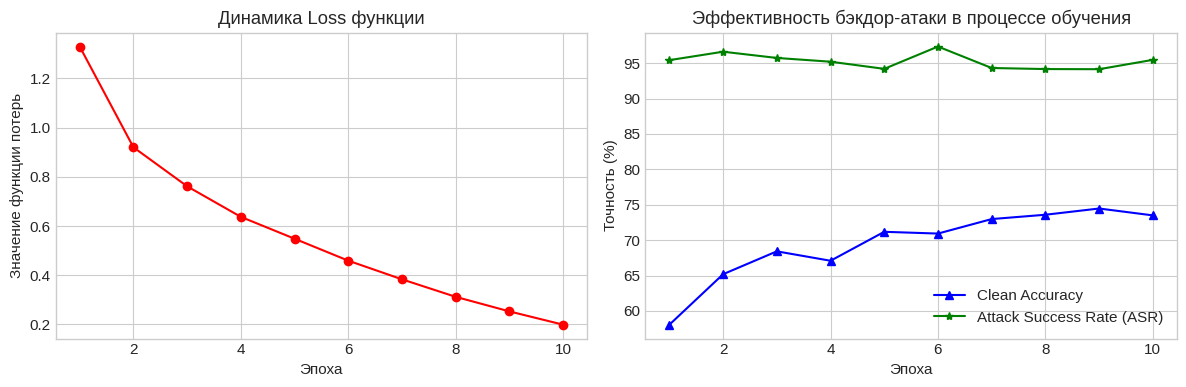

In [ ]:
#@title 2. Реализация и обучение модели ResNet-18

from torchvision.models import resnet18

# Инициализация ResNet-18
model = resnet18(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels, _ in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return total_loss / total, 100. * correct / total

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            images, labels = batch[0].to(device), batch[1].to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

# Цикл обучения
epochs = 10
history = {'epoch': [], 'loss': [], 'clean_acc': [], 'asr': []}

print("Запуск обучения ResNet-18:"+"\n")
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    clean_acc = evaluate(model, clean_test_loader)
    attack_acc = evaluate(model, poisoned_test_loader)

    history['epoch'].append(epoch + 1)
    history['loss'].append(train_loss)
    history['clean_acc'].append(clean_acc)
    history['asr'].append(attack_acc)

    print(f"Эпоха {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | "
          f"Clean Test Acc: {clean_acc:.2f}% | Attack Success Rate (ASR): {attack_acc:.2f}%")

# Вывод графиков обучения модели для вставки в отчет
print(" ")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['loss'], 'ro-', label='Loss')
plt.xlabel('Эпоха')
plt.ylabel('Значение функции потерь')
plt.title('Динамика Loss функции')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['clean_acc'], 'b^-', label='Clean Accuracy')
plt.plot(history['epoch'], history['asr'], 'g*-', label='Attack Success Rate (ASR)')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.title('Эффективность бэкдор-атаки в процессе обучения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#@title 3. Извлечение скрытых векторов активаций нейросети

activations = []
def get_activation_hook(module, input, output):
    flattened = torch.flatten(output, 1)
    activations.append(flattened.cpu().numpy())

# Регистрация хука на предпоследний слой (avgpool)
hook_handle = model.avgpool.register_forward_hook(get_activation_hook)

model.eval()
all_labels, all_poison_flags = [], []
activations = []

print("Извлечение векторов скрытых активаций:")
with torch.no_grad():
    for batch in train_loader:
        images = batch[0].to(device)
        labels = batch[1]
        poison_flags = batch[2] if len(batch) > 2 else torch.zeros_like(labels)

        _ = model(images)
        all_labels.extend(labels.numpy())
        all_poison_flags.extend(poison_flags.numpy())

hook_handle.remove()

features_matrix = np.concatenate(activations, axis=0)
labels_array = np.array(all_labels)
poison_flags_array = np.array(all_poison_flags)

# Выделяем подмножество данных исключительно для целевого скомпрометированного класса 0
class_mask = (labels_array == 0)
class_features = features_matrix[class_mask]
class_poison_flags = poison_flags_array[class_mask]
total_poison = np.sum(class_poison_flags == 1)

print(f"\nСбор завершен. Целевой класс содержит {len(class_features)} объектов.")
print(f"Реальный состав: чистых — {np.sum(class_poison_flags == 0)}, отравленных — {total_poison}")

Извлечение векторов скрытых активаций:

Сбор завершен. Целевой класс содержит 9524 объектов.
Реальный состав: чистых — 4524, отравленных — 5000


Выполнение FastICA
Запуск базовой кластеризации K-Means (K=2)

Результаты оригинального метода из статьи:

Изолировано в макро-кластер яда: 4682 объектов
True Positives (Обнаруженный яд): 4659 из 5000 (93.18%)
False Positives (Ошибочно удаленные чистые): 23



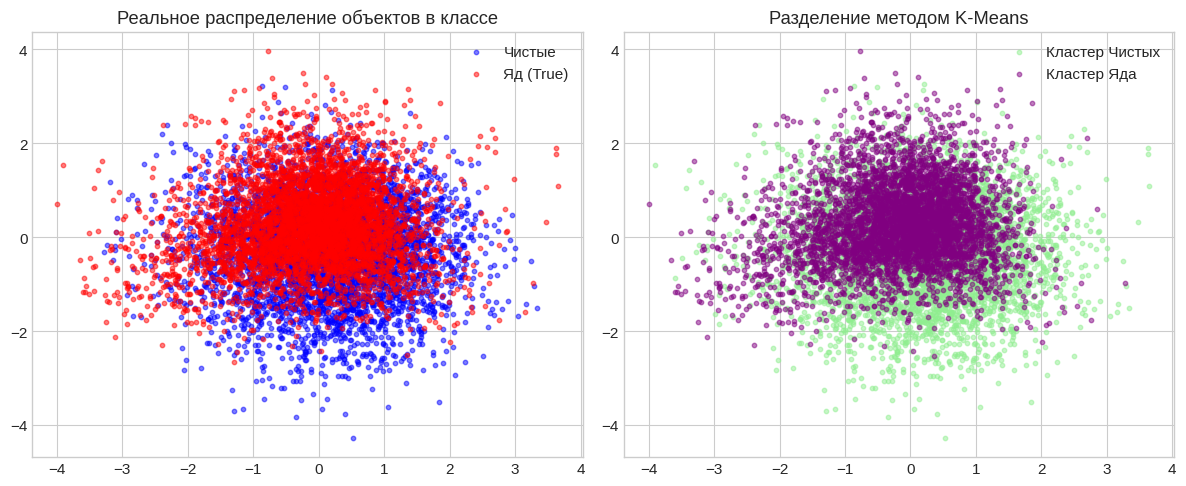

In [ ]:
#@title 4. Реализация оригинального метода из статьи (Activation Clustering)

print("Выполнение FastICA")
ica = FastICA(n_components=10, random_state=42, max_iter=1000)
features_reduced = ica.fit_transform(class_features)

print("Запуск базовой кластеризации K-Means (K=2)")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_reduced)

# Вычисление распределения объектов по макро-кластерам
size_c0 = np.sum(cluster_labels == 0)
size_c1 = np.sum(cluster_labels == 1)
poison_cluster_idx = 1 if size_c1 < size_c0 else 0
clean_cluster_idx = 1 - poison_cluster_idx

# Подсчет метрик базовой фильтрации (Этап 1)
detected_poison_mask_k = (cluster_labels == poison_cluster_idx)
base_tp = np.sum(class_poison_flags[detected_poison_mask_k] == 1)
base_fp = np.sum(class_poison_flags[detected_poison_mask_k] == 0)
base_tp_rate = (base_tp / total_poison) * 100

print(f"\nРезультаты оригинального метода из статьи:\n")
print(f"Изолировано в макро-кластер яда: {np.sum(detected_poison_mask_k)} объектов")
print(f"True Positives (Обнаруженный яд): {base_tp} из {total_poison} ({base_tp_rate:.2f}%)")
print(f"False Positives (Ошибочно удаленные чистые): {base_fp}\n")

# Отрисовка двухмерного пространства признаков
pca_2d = PCA(n_components=2, random_state=42)
features_pca = pca_2d.fit_transform(features_reduced)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(features_pca[class_poison_flags==0, 0], features_pca[class_poison_flags==0, 1], alpha=0.5, label='Чистые', c='blue', s=10)
plt.scatter(features_pca[class_poison_flags==1, 0], features_pca[class_poison_flags==1, 1], alpha=0.5, label='Яд (True)', c='red', s=10)
plt.title('Реальное распределение объектов в классе')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(features_pca[cluster_labels==clean_cluster_idx, 0], features_pca[cluster_labels==clean_cluster_idx, 1], alpha=0.5, label='Кластер Чистых', c='lightgreen', s=10)
plt.scatter(features_pca[cluster_labels==poison_cluster_idx, 0], features_pca[cluster_labels==poison_cluster_idx, 1], alpha=0.5, label='Кластер Яда', c='purple', s=10)
plt.title('Разделение методом K-Means')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#@title 5. Реализация улучшения: Итеративное удаление и периферийная дочистка

print("Запуск двухстадийной гибридной фильтрации:\n")

# СТАДИЯ 1: Исключаем основной макро-кластер яда (удаляем то, что уже нашли)
stage1_clean_mask = (cluster_labels == clean_cluster_idx)
features_stage2 = features_reduced[stage1_clean_mask]
flags_stage2 = class_poison_flags[stage1_clean_mask]

print(f"[Стадия 1] Успешно удалено основного яда: {base_tp} штук.")
print(f"           Оставлено данных для повторной проверки: {len(features_stage2)} объектов (из них скрытого яда: {np.sum(flags_stage2 == 1)}).")

# СТАДИЯ 2: Повторная проверка остатка выборки (поиск периферийных выбросов)
centroid = np.mean(features_stage2, axis=0)
distances_to_centroid = np.linalg.norm(features_stage2 - centroid, axis=1)

mean_dist = np.mean(distances_to_centroid)
std_dist = np.std(distances_to_centroid)
z_scores = (distances_to_centroid - mean_dist) / std_dist

# Адаптивный порог: берем объекты, которые дальше среднего расстояния от центра (Z-score > 1.0)
stage2_anomaly_mask = (z_scores > 1.0)

# Объединяем логику обнаружения обеих стадий
detected_as_poison_total = np.zeros(len(class_features), dtype=bool)
detected_as_poison_total[cluster_labels == poison_cluster_idx] = True # Яд с 1-го шага

# Проекция локальной маски 2-й стадии обратно на исходные глобальные индексы класса
stage2_global_indices = np.where(stage1_clean_mask)[0]
detected_in_stage2 = stage2_global_indices[stage2_anomaly_mask]
detected_as_poison_total[detected_in_stage2] = True # Дочищенный яд со 2-го шага

# Расчет расширенных метрик качества фильтрации
total_clean_objects = np.sum(class_poison_flags == 0) # Всего чистых элементов в классе

# Метрики базового метода
base_tp = np.sum(class_poison_flags[detected_poison_mask_k] == 1)
base_fp = np.sum(class_poison_flags[detected_poison_mask_k] == 0)
base_tp_rate = (base_tp / total_poison) * 100
base_fpr = (base_fp / total_clean_objects) * 100

# Метрики гибридного метода
hybrid_tp = np.sum(class_poison_flags[detected_as_poison_total] == 1)
hybrid_fp = np.sum(class_poison_flags[detected_as_poison_total] == 0)
hybrid_tp_rate = (hybrid_tp / total_poison) * 100
hybrid_fpr = (hybrid_fp / total_clean_objects) * 100

print(f"\n[Стадия 2] Повторная проверка выявила еще {np.sum(stage2_anomaly_mask)} аномальных объектов на периферии.")
print(f"           (Из них подтвержденного яда: {np.sum(flags_stage2[stage2_anomaly_mask] == 1)}, ложных срабатываний: {np.sum(flags_stage2[stage2_anomaly_mask] == 0)})")

Запуск двухстадийной гибридной фильтрации:

[Стадия 1] Успешно удалено основного яда: 4659 штук.
           Оставлено данных для повторной проверки: 4842 объектов (из них скрытого яда: 341).

[Стадия 2] Повторная проверка выявила еще 701 аномальных объектов на периферии.
           (Из них подтвержденного яда: 145, ложных срабатываний: 556)



                                        СРАВНИТЕЛЬНЫЙ АНАЛИЗ ЭФФЕКТИВНОСТИ СИСТЕМ ЗАЩИТЫ
                   Показатель эффективности защиты Базовый метод (K-Means) Предложенное улучшение (Гибрид)
               Изолировано объектов всего (Защита)                    4682                            5383
           Успешно обнаружено яда (True Positives)                    4659                            4804
   Доля обнаружения яда (True Positive Rate / TPR)                  93.18%                          96.08%
Ошибочно удалено чистых объектов (False Positives)                      23                             579
    Доля ложных срабатываний (False PF Rate / FPR)                   0.51%                          12.80%


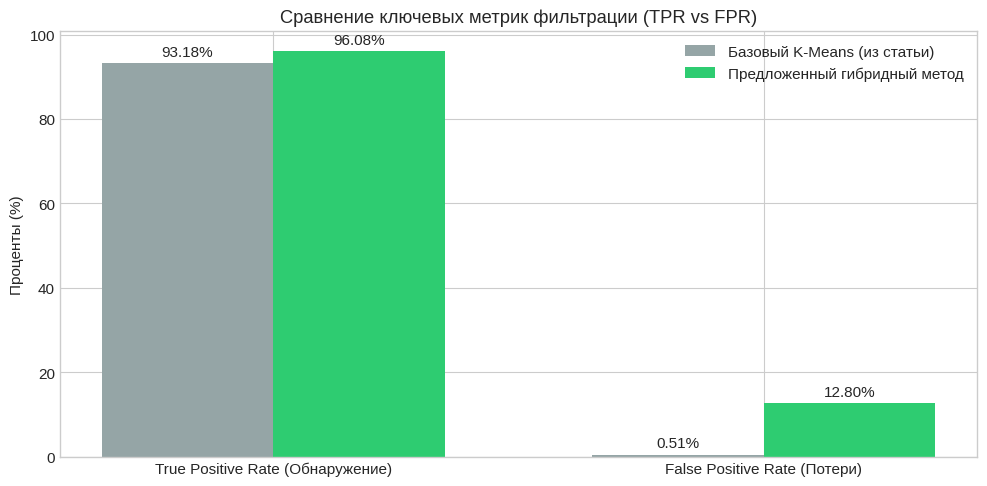

In [ ]:
#@title 6. Анализ результатов и построение графиков

# Автоматическое формирование сравнительной таблицы результатов
metrics_data = {
    'Показатель эффективности защиты': [
        'Изолировано объектов всего (Защита)',
        'Успешно обнаружено яда (True Positives)',
        'Доля обнаружения яда (True Positive Rate / TPR)',
        'Ошибочно удалено чистых объектов (False Positives)',
        'Доля ложных срабатываний (False PF Rate / FPR)'
    ],
    'Базовый метод (K-Means)': [
        np.sum(detected_poison_mask_k),
        base_tp,
        f"{base_tp_rate:.2f}%",
        base_fp,
        f"{base_fpr:.2f}%"
    ],
    'Предложенное улучшение (Гибрид)': [
        np.sum(detected_as_poison_total),
        hybrid_tp,
        f"{hybrid_tp_rate:.2f}%",
        hybrid_fp,
        f"{hybrid_fpr:.2f}%"
    ]
}

df_comparison = pd.DataFrame(metrics_data)
print("\n" + "="*128)
print("                                        СРАВНИТЕЛЬНЫЙ АНАЛИЗ ЭФФЕКТИВНОСТИ СИСТЕМ ЗАЩИТЫ")
print("="*128)
print(df_comparison.to_string(index=False))
print("="*128)

# Построение гистограммы сравнения результатов
categories = ['True Positive Rate (Обнаружение)', 'False Positive Rate (Потери)']
base_rates = [base_tp_rate, base_fpr]
hybrid_rates = [hybrid_tp_rate, hybrid_fpr]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, base_rates, width, label='Базовый K-Means (из статьи)', color='#95a5a6')
rects2 = ax.bar(x + width/2, hybrid_rates, width, label='Предложенный гибридный метод', color='#2ecc71')

ax.set_ylabel('Проценты (%)')
ax.set_title('Сравнение ключевых метрик фильтрации (TPR vs FPR)')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Добавление подписей процентов на графики
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()